<a href="https://colab.research.google.com/github/LavanyaMaruthachalam/Acoustic-Bowel-Movements/blob/main/Acoustic_V1_Bowl_Movements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Upload your files to Colab (zip or csv + wavs)

In [20]:
import os, glob
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from google.colab import files
import matplotlib.pyplot as plt
import librosa, librosa.display
import os, glob, zipfile
from IPython.display import Audio, display
import plotly.express as px


In [21]:

uploaded = files.upload()  # choose your zip or csv/wavs
print("Uploaded:", list(uploaded.keys()))


Saving dataset_v2_filtered.zip to dataset_v2_filtered (1).zip
Uploaded: ['dataset_v2_filtered (1).zip']


2)Uploaded a ZIP, unzip it    3) Locate and load dataset_metadata.csv

In [22]:
# Find the first uploaded zip
zip_files = [f for f in uploaded.keys() if f.lower().endswith(".zip")]

if zip_files:
    zip_path = zip_files[0]
    print("Unzipping:", zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("data")
    print("Extracted to: data/")
else:
    print("No zip uploaded. If you uploaded csv/wavs directly, skip this step.")



# Search for the metadata file
candidates = glob.glob("**/dataset_metadata.csv", recursive=True)
print("Found metadata files:", candidates)

if not candidates:
    raise FileNotFoundError("dataset_metadata.csv not found. Upload it or unzip the correct folder.")

meta_path = candidates[0]
df_raw = pd.read_csv(meta_path)
print("Using:", meta_path)
print(len(df_raw))
df_raw.head(5)


Unzipping: dataset_v2_filtered (1).zip
Extracted to: data/
Found metadata files: ['data/dataset_metadata.csv']
Using: data/dataset_metadata.csv
7112


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav


In [23]:
# Remove outlier session 7

print("Rows before filter:", len(df_raw))
print("Sessions:", df_raw["session_id"].nunique())

OUTLIER_SESSION_ID = 7
df = df_raw[df_raw["session_id"] != OUTLIER_SESSION_ID].copy()

print("Rows after filter:", len(df))
print("Sessions:", df["session_id"].nunique())

Rows before filter: 7112
Sessions: 11
Rows after filter: 6348
Sessions: 10


# 4) Basic metadata inspection + quick plots  and 5) Time-to-defecation vs duration (scatter)

Shape: (6348, 10)

Columns:
 ['filename', 'session_id', 'datetime', 'chunk_index', 'minutes_until_defecation', 'minutes_since_last_defecation', 'minutes_since_meal', 'minutes_since_wake', 'duration', 'original_file']

Missing values (%):
 filename                          0.00
session_id                        0.00
datetime                          0.00
chunk_index                       0.00
minutes_until_defecation          0.50
minutes_since_last_defecation    13.04
minutes_since_meal                1.01
minutes_since_wake                0.00
duration                          0.00
original_file                     0.00
dtype: float64


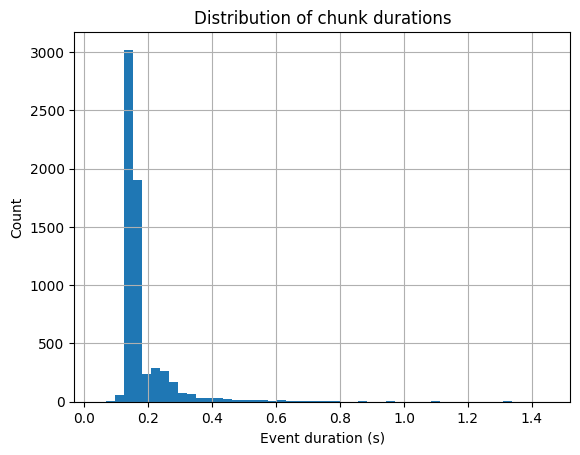

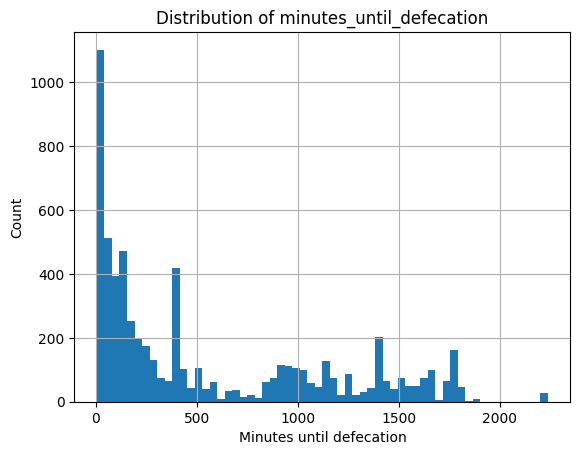

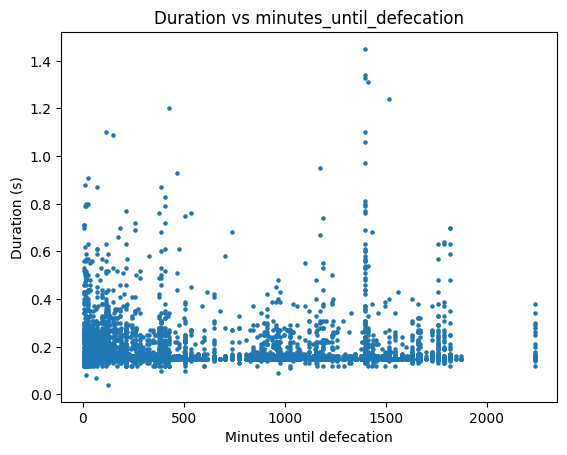

In [24]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values (%):\n", (df.isna().mean()*100).round(2))

# Duration distribution
plt.figure()
df["duration"].dropna().hist(bins=50)
plt.xlabel("Event duration (s)")
plt.ylabel("Count")
plt.title("Distribution of chunk durations")
plt.show()

# minutes_until_defecation distribution (ignore NaNs)
plt.figure()
df["minutes_until_defecation"].dropna().hist(bins=60)
plt.xlabel("Minutes until defecation")
plt.ylabel("Count")
plt.title("Distribution of minutes_until_defecation")
plt.show()

plt.figure()
tmp = df.dropna(subset=["minutes_until_defecation", "duration"])
plt.scatter(tmp["minutes_until_defecation"], tmp["duration"], s=5)
plt.xlabel("Minutes until defecation")
plt.ylabel("Duration (s)")
plt.title("Duration vs minutes_until_defecation")
plt.show()


6) Load and visualize a few WAV chunks (waveform + spectrogram + playback)

This will:

find the chunks/ folder

pick a few chunks nearest to defecation (small minutes) if available

plot waveform + spectrogram

Found chunks folders: ['data/chunks']
Using chunks dir: data/chunks

File: 10_30_1824_chunk_021.wav | sr=8000 | duration=0.16s | minutes_until_defecation=6.0


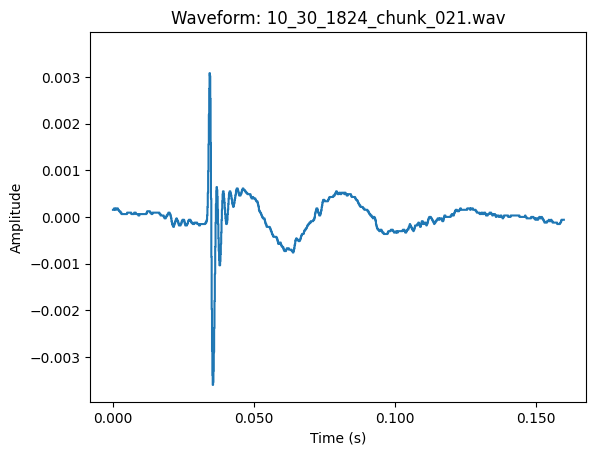

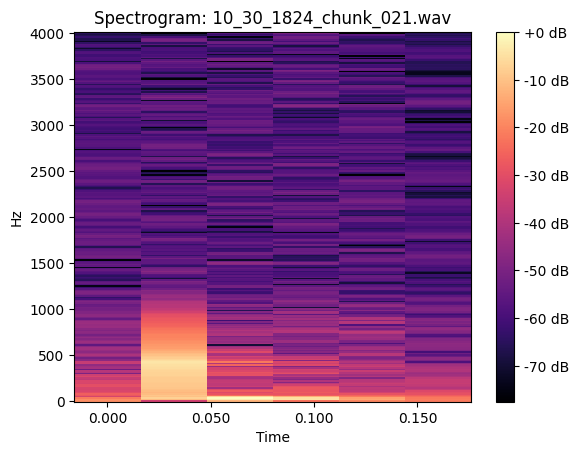


File: 10_30_1824_chunk_020.wav | sr=8000 | duration=0.24s | minutes_until_defecation=6.0


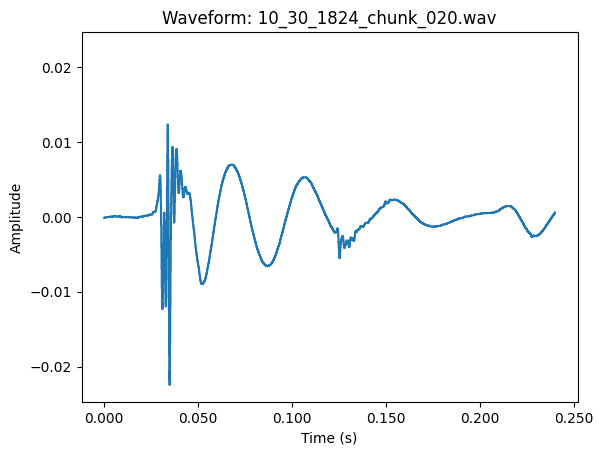

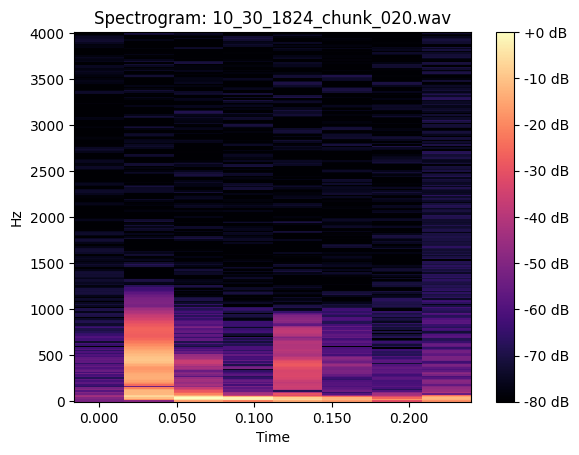


File: 10_30_1824_chunk_043.wav | sr=8000 | duration=0.24s | minutes_until_defecation=6.0


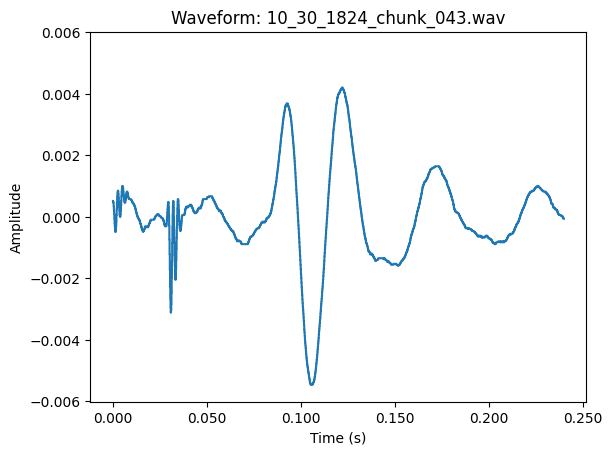

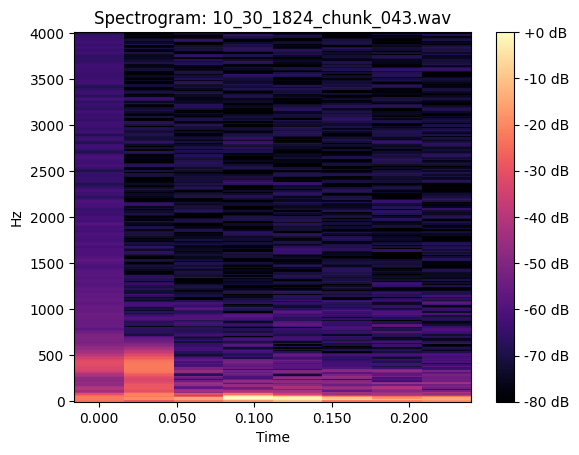


File: 10_30_1824_chunk_042.wav | sr=8000 | duration=0.43s | minutes_until_defecation=6.0


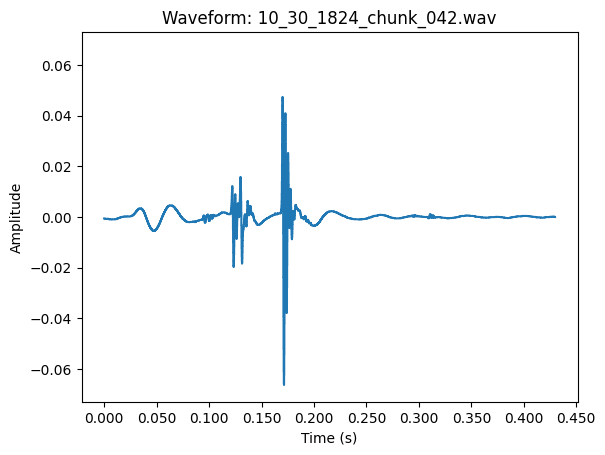

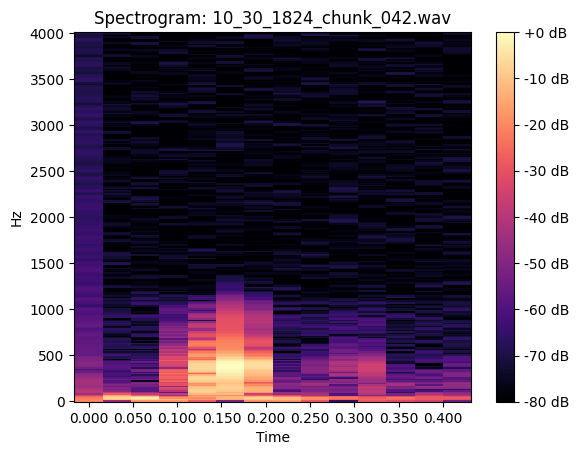


File: 10_30_1824_chunk_041.wav | sr=8000 | duration=0.39s | minutes_until_defecation=6.0


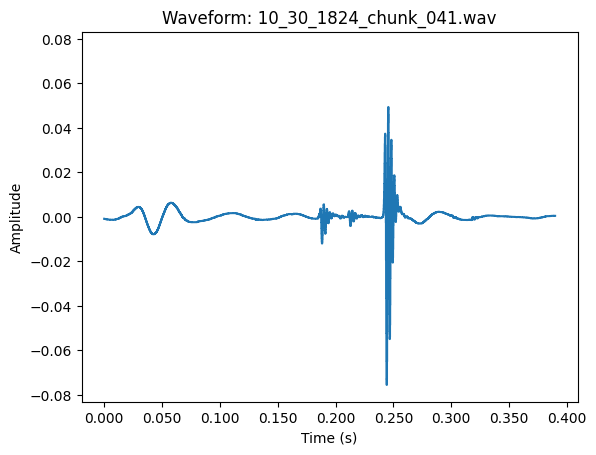

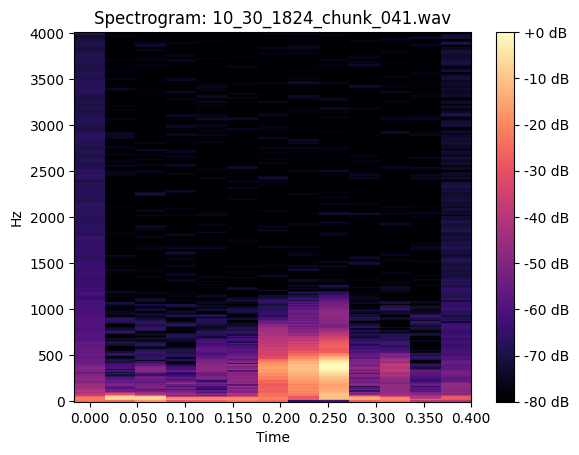

In [25]:
# Find chunks folder
chunks_dirs = [p for p in glob.glob("**/chunks", recursive=True) if os.path.isdir(p)]
print("Found chunks folders:", chunks_dirs)

if not chunks_dirs:
    print("No chunks/ folder found. Upload wav files or unzip dataset folder containing chunks/")
else:
    chunks_dir = chunks_dirs[0]
    print("Using chunks dir:", chunks_dir)

    # Choose 5 samples: closest to defecation if label exists, else random
    if "minutes_until_defecation" in df.columns and df["minutes_until_defecation"].notna().any():
        sample_df = df.dropna(subset=["minutes_until_defecation"]).sort_values("minutes_until_defecation").head(5)
    else:
        sample_df = df.sample(10, random_state=42)

    for i, row in sample_df.iterrows():
        wav_path = os.path.join(chunks_dir, row["filename"])
        if not os.path.exists(wav_path):
            print("Missing wav:", wav_path)
            continue

        y, sr = librosa.load(wav_path, sr=None, mono=True)

        print(f"\nFile: {row['filename']} | sr={sr} | duration={len(y)/sr:.2f}s | minutes_until_defecation={row.get('minutes_until_defecation', None)}")

        # Waveform
        plt.figure()
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Waveform: {row['filename']}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.show()

        # Spectrogram (dB)
        S = np.abs(librosa.stft(y, n_fft=512, hop_length=256))
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        plt.figure()
        librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis="time", y_axis="hz")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram: {row['filename']}")
        plt.show()

        # Playback
        display(Audio(y, rate=sr))




In [26]:
DATASET_ROOT = "data"
META_PATH = os.path.join(DATASET_ROOT, "dataset_metadata.csv")
CHUNKS_DIR = os.path.join(DATASET_ROOT, "chunks")

print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))


META exists: True
CHUNKS dir exists: True


In [27]:

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()


Rows: 6348
Columns: ['filename', 'session_id', 'datetime', 'chunk_index', 'minutes_until_defecation', 'minutes_since_last_defecation', 'minutes_since_meal', 'minutes_since_wake', 'duration', 'original_file']


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav


Step 2: Keep events with valid minutes_until_defecation


In [28]:
df2 = df[df["minutes_until_defecation"].notna()].copy()
df2["minutes_until_defecation"] = df2["minutes_until_defecation"].astype(float)

print("Events with target:", len(df2))
print("Target range (min):", df2["minutes_until_defecation"].min(), "to", df2["minutes_until_defecation"].max())
df2[["filename", "session_id", "datetime", "minutes_until_defecation", "duration"]].head()


Events with target: 6316
Target range (min): 6.0 to 2238.0


,filename,session_id,datetime,minutes_until_defecation,duration
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1431.0,0.15
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,1431.0,0.20
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,1431.0,0.15
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,1431.0,0.17
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,1431.0,0.16


# CODE SET :4


In [29]:
# ============================================================
# CODE SET 4 (Merged): Hybrid (two rolloffs + two effect sizes)
#                    + Per-session extraction + session summary
# ============================================================

# -------------------------
# 1) Paths + Output
OUT_DIR = "results_code_set4"
os.makedirs(OUT_DIR, exist_ok=True)

print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))

# -------------------------
# 2) Global Parameters
# -------------------------
# Filtering
OUTLIER_SESSION_ID = 7      # set None if you do not want to exclude
DROP_OUTLIER_SESSION = True # set False if you want all sessions

# High-pass filter
HP_CUTOFF_HZ = 20
HP_ORDER = 2

# STFT for feature extraction
STFT_WINDOW = "hann"
STFT_BASE_NFFT_16K = 1024
STFT_BASE_NFFT_8K = 512
MIN_SPECTRAL_NPERSEG = 32   # below this: spectral features set to 0

# Time-to-defecation bins (minutes)
bins = [0, 30, 60, 120, 240, 360, 480, 720, 1440, 999999]
labels_near_to_far = ["0-30m","30-60m","1-2h","2-4h","4-6h","6-8h","8-12h","12-24h",">24h"]
order_far_to_near = [">24h","12-24h","8-12h","6-8h","4-6h","2-4h","1-2h","30-60m","0-30m"]

# Session baseline (z-score)
BASELINE_MIN = 480          # 8 hours
MIN_BASELINE_N = 10         # baseline must have >= this many events

# Near vs Far windows for Mann-Whitney and effect sizes
NEAR_MAX = 60
FAR_MIN = 480

# Which features to z-score (keep it focused + interpretable)
Z_FEATURES = ["feat_centroid_mean", "feat_flatness_mean", "feat_duration_s", "feat_env_mean", "feat_zcr"]

# -------------------------
# 3) Utility Functions
# -------------------------
def teager_kaiser_energy(x):
    x = np.asarray(x)
    if len(x) < 3:
        return np.array([0.0])
    return x[1:-1]**2 - x[:-2] * x[2:]

def highpass(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER):
    if len(x) < 64 or sr < 100:
        return x
    b, a = signal.butter(order, cutoff_hz / (sr / 2), btype="highpass")
    return signal.filtfilt(b, a, x)

def add_bins(df_):
    df_ = df_.copy()
    df_["t2d_bin"] = pd.cut(
        df_["minutes_until_defecation"],
        bins=bins,
        labels=labels_near_to_far,
        include_lowest=True
    )
    df_["t2d_bin"] = pd.Categorical(df_["t2d_bin"],
                                    categories=order_far_to_near,
                                    ordered=True)
    return df_

def rank_biserial_from_U(U, n1, n2):
    # rbc = 1 - 2U/(n1*n2) formula
    return 1 - (2 * U) / (n1 * n2)

def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    gt = 0
    lt = 0
    for x in a:
        gt += np.sum(x > b)
        lt += np.sum(x < b)
    return (gt - lt) / (len(a) * len(b))

def bootstrap_ci_median(x, n_boot=800, ci=95, seed=42):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    meds = []
    for _ in range(n_boot):
        samp = rng.choice(x, size=len(x), replace=True)
        meds.append(np.median(samp))
    lo = np.percentile(meds, (100-ci)/2)
    hi = np.percentile(meds, 100-(100-ci)/2)
    return np.median(x), lo, hi

def _rolloff95(f, M):
    """
    f: (F,) frequency bins
    M: (F,T) magnitude or power matrix
    returns rolloff per frame (T,)
    """
    cumsum = np.cumsum(M, axis=0)
    total = cumsum[-1, :] + 1e-12
    T = cumsum.shape[1]
    roll = np.zeros(T, dtype=np.float32)
    for i in range(T):
        idx = np.searchsorted(cumsum[:, i], 0.95 * total[i])
        idx = min(idx, len(f) - 1)
        roll[i] = f[idx]
    return roll

# -------------------------
# 4) Hybrid Feature Extraction
#     Includes BOTH rolloffs:
#       - feat_roll95_amp_mean (mag-based)
#       - feat_roll95_pow_mean (power-based)
#     Includes BOTH effect-size-ready features
# -------------------------
def extract_features_hybrid(wav_path):
    x, sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    # high-pass
    x = highpass(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER)

    # time-domain
    dur = len(x) / sr
    rms = float(np.sqrt(np.mean(x**2) + 1e-12))
    peak = float(np.max(np.abs(x)) + 1e-12)
    zcr = float(np.mean(np.abs(np.diff(np.sign(x))) > 0))
    peak_to_rms = float(peak / (rms + 1e-12))

    # envelope
    env = np.abs(signal.hilbert(x)) + 1e-12
    env_mean = float(np.mean(env))
    env_std = float(np.std(env))
    env_max = float(np.max(env))
    env_crest = float(env_max / (env_mean + 1e-12))

    # STFT
    base_n_fft = STFT_BASE_NFFT_16K if sr >= 16000 else STFT_BASE_NFFT_8K
    nperseg = min(base_n_fft, len(x))

    if nperseg < MIN_SPECTRAL_NPERSEG:
        centroid = np.array([0.0])
        flatness = np.array([0.0])
        roll95_amp = np.array([0.0])
        roll95_pow = np.array([0.0])
        flux_mean = 0.0
    else:
        hop = max(1, nperseg // 4)
        noverlap = min(nperseg - 1, nperseg - hop)

        f, t, Z = signal.stft(
            x,
            fs=sr,
            nperseg=nperseg,
            noverlap=noverlap,
            window=STFT_WINDOW,
            padded=False,
            boundary=None
        )
        mag = np.abs(Z) + 1e-12
        pow_ = mag**2


        #centroid=∑magnitude//∑f⋅magnitude
        centroid = (f[:, None] * mag).sum(axis=0) / mag.sum(axis=0)
        flatness = np.exp(np.mean(np.log(mag), axis=0)) / (np.mean(mag, axis=0) + 1e-12)

        # BOTH rolloffs
        roll95_amp = _rolloff95(f, mag)
        roll95_pow = _rolloff95(f, pow_)

        # flux
        flux = np.sqrt(np.sum(np.diff(mag, axis=1)**2, axis=0))
        flux_mean = float(np.mean(flux)) if flux.size else 0.0

    # TKEO
    tkeo = np.abs(teager_kaiser_energy(x))
    tkeo_mean = float(np.mean(tkeo)) if tkeo.size else 0.0
    tkeo_max = float(np.max(tkeo)) if tkeo.size else 0.0

    return {
        "sr": int(sr),
        "feat_duration_s": float(dur),
        "feat_rms": rms,
        "feat_log_rms": float(np.log(rms + 1e-12)),
        "feat_peak_to_rms": peak_to_rms,
        "feat_zcr": zcr,
        "feat_env_mean": env_mean,
        "feat_env_std": env_std,
        "feat_env_crest": env_crest,
        "feat_centroid_mean": float(np.mean(centroid)),
        "feat_centroid_std": float(np.std(centroid)),
        "feat_flatness_mean": float(np.mean(flatness)),
        "feat_roll95_amp_mean": float(np.mean(roll95_amp)),
        "feat_roll95_pow_mean": float(np.mean(roll95_pow)),
        "feat_flux_mean": flux_mean,
        "feat_tkeo_mean": tkeo_mean,
        "feat_tkeo_max": tkeo_max,

        # Logged params for reproducibility
        "stft_nperseg": int(nperseg),
        "stft_hop": int(max(1, nperseg // 4)) if nperseg >= MIN_SPECTRAL_NPERSEG else 0,
        "stft_window": STFT_WINDOW,
        "hp_cutoff_hz": HP_CUTOFF_HZ,
        "hp_order": HP_ORDER,
    }

# -------------------------
# 5) Load metadata safely (no overwriting filtered df)
# -------------------------
df_raw = pd.read_csv(META_PATH)
print("Rows raw:", len(df_raw), "Sessions raw:", df_raw["session_id"].nunique())

df = df_raw.copy()

if DROP_OUTLIER_SESSION and OUTLIER_SESSION_ID is not None:
    df = df[df["session_id"] != OUTLIER_SESSION_ID].copy()
    print("Removed session:", OUTLIER_SESSION_ID)

print("Rows working df:", len(df), "Sessions working df:", df["session_id"].nunique())

# Optional guardrail
if DROP_OUTLIER_SESSION and OUTLIER_SESSION_ID is not None:
    assert OUTLIER_SESSION_ID not in df["session_id"].unique(), "Session leaked back into df!"

# Drop rows that cannot be used for time-to-event analysis (NaN target)
df = df.dropna(subset=["minutes_until_defecation"]).copy()
print("Rows with valid minutes_until_defecation:", len(df))

# -------------------------
# 6) Extract features for ALL events (global dataset)
# -------------------------
feature_rows = []
missing = 0

for _, row in df.iterrows():
    wav_path = os.path.join(CHUNKS_DIR, row["filename"])
    if not os.path.exists(wav_path):
        missing += 1
        continue
    feats = extract_features_hybrid(wav_path)
    feats["filename"] = row["filename"]
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print("Extracted feature rows:", len(feat_df), "Missing wavs:", missing)

data = df.merge(feat_df, on="filename", how="inner")
print("Merged rows:", len(data))

global_csv = os.path.join(OUT_DIR, "bowel_event_features_codeset4.csv")
data.to_csv(global_csv, index=False)
print("Saved global features:", global_csv)

# -------------------------
# 7) Global Binning (far -> near order)
# -------------------------
data = add_bins(data)
bin_counts = data["t2d_bin"].value_counts().sort_index()
print("\nBin counts (far -> near):")
print(bin_counts)

# -------------------------
# 8) Global Session Normalization (z-scores)
# -------------------------
data_norm = data.copy()
for f in Z_FEATURES:
    data_norm[f + "_z"] = np.nan
data_norm["baseline_n"] = 0

def session_zscore(df_sess):
    df_sess = df_sess.copy()
    base = df_sess[df_sess["minutes_until_defecation"] >= BASELINE_MIN]
    df_sess["baseline_n"] = len(base)

    if len(base) < MIN_BASELINE_N:
        return df_sess

    mu = base[Z_FEATURES].mean()
    sd = base[Z_FEATURES].std(ddof=0).replace(0, np.nan)

    for f in Z_FEATURES:
        df_sess[f + "_z"] = (df_sess[f] - mu[f]) / sd[f]
    return df_sess

data_norm = data_norm.groupby("session_id", group_keys=False).apply(session_zscore)
data_norm = add_bins(data_norm)

norm_csv = os.path.join(OUT_DIR, "bowel_event_features_codeset4_norm.csv")
data_norm.to_csv(norm_csv, index=False)
print("Saved normalized features:", norm_csv)

# -------------------------
# 9) Global Stats Table (Spearman + MW + RBC + Cliff)
# -------------------------
feature_cols = [c for c in data.columns if c.startswith("feat_") and not c.endswith("_z")]

tmp = data.dropna(subset=["minutes_until_defecation"]).copy()
near_df = tmp[tmp["minutes_until_defecation"] <= NEAR_MAX]
far_df  = tmp[tmp["minutes_until_defecation"] >= FAR_MIN]
print("\nNear N:", len(near_df), "Far N:", len(far_df))

rows = []
for feat in feature_cols:
    # Spearman
    t = tmp.dropna(subset=[feat, "minutes_until_defecation"])
    if len(t) < 20:
        rho, p_s = np.nan, np.nan
    else:
        rho, p_s = stats.spearmanr(t[feat].values, t["minutes_until_defecation"].values)

    # Mann-Whitney + effect sizes
    a = near_df[feat].dropna().values
    b = far_df[feat].dropna().values
    if len(a) < 30 or len(b) < 30:
        mw_p = np.nan
        rbc = np.nan
        cd = np.nan
    else:
        U, mw_p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rbc = rank_biserial_from_U(U, len(a), len(b))
        cd = cliffs_delta(a, b)

    rows.append({
        "feature": feat,
        "spearman_rho": rho,
        "spearman_p": p_s,
        "mw_p": mw_p,
        "rank_biserial": rbc,
        "cliffs_delta": cd,
        "near_N": len(a),
        "far_N": len(b),
    })

stats_df = pd.DataFrame(rows).sort_values("mw_p")
stats_csv = os.path.join(OUT_DIR, "global_stats_codeset4.csv")
stats_df.to_csv(stats_csv, index=False)
print("\nSaved global stats:", stats_csv)

# Show the two rolloff variants side-by-side quickly
roll_compare = stats_df[stats_df["feature"].isin(["feat_roll95_amp_mean", "feat_roll95_pow_mean"])]
print("\nRolloff comparison (amp vs power):")
print(roll_compare[["feature","spearman_rho","spearman_p","mw_p","rank_biserial","cliffs_delta","near_N","far_N"]])

# -------------------------
# 10) Global Plots (Raw medians, far -> near)
# -------------------------
top_feats = stats_df.sort_values("spearman_p").head(6)["feature"].tolist()

for c in top_feats:
    grp = data.groupby("t2d_bin", observed=True)[c].median().reindex(order_far_to_near)
    plt.figure()
    plt.plot(grp.index.astype(str), grp.values, marker="o")
    plt.title(f"Global median: {c} (far -> near)")
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel(c)
    plt.xticks(rotation=45)
    plt.tight_layout()
    outpng = os.path.join(OUT_DIR, f"global_raw_{c}.png")
    plt.savefig(outpng, dpi=150)
    plt.close()

# -------------------------
# 11) Global Plots (Z-score medians + 95% bootstrap CI)
# -------------------------
important_feats_z = ["feat_centroid_mean_z", "feat_flatness_mean_z", "feat_duration_s_z"]

for fz in important_feats_z:
    rows_ci = []
    for b in order_far_to_near:
        vals = data_norm.loc[data_norm["t2d_bin"] == b, fz].values
        med, lo, hi = bootstrap_ci_median(vals, n_boot=800, ci=95, seed=42)
        rows_ci.append((b, med, lo, hi, np.sum(~np.isnan(vals))))
    plot_df = pd.DataFrame(rows_ci, columns=["bin","median","ci_low","ci_high","N"])

    plt.figure()
    plt.errorbar(
        plot_df["bin"],
        plot_df["median"],
        yerr=[plot_df["median"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["median"]],
        fmt="o-"
    )
    plt.axhline(0, linestyle="--", color="gray", label="Baseline (z=0)")
    plt.title(f"Global session-normalized {fz} (median ± 95% bootstrap CI)")
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel("z-score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    outpng = os.path.join(OUT_DIR, f"global_z_{fz}.png")
    plt.savefig(outpng, dpi=150)
    plt.close()

    # Save CI table
    ci_csv = os.path.join(OUT_DIR, f"global_ci_{fz}.csv")
    plot_df.to_csv(ci_csv, index=False)

# -------------------------
# 12) Per-session Extraction + Plots + Session Summary
# -------------------------
SESSION_SUMMARY = []
all_sessions = sorted(data["session_id"].unique())

def plot_trend(df_, col, title, outpng):
    grp = df_.groupby("t2d_bin", observed=True)[col].median().reindex(order_far_to_near)
    plt.figure()
    plt.plot(grp.index.astype(str), grp.values, marker="o")
    plt.title(title)
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(outpng, dpi=150)
    plt.close()

for sid in all_sessions:
    sess_dir = os.path.join(OUT_DIR, f"session_{sid}")
    os.makedirs(sess_dir, exist_ok=True)

    df_sess = data[data["session_id"] == sid].copy()
    df_sess = add_bins(df_sess)

    # Recompute z-scores per session (clean and explicit)
    df_sess_norm = session_zscore(df_sess)

    # Save per-session CSV
    csv_path = os.path.join(sess_dir, f"features_session_{sid}.csv")
    df_sess_norm.to_csv(csv_path, index=False)

    # Raw plots (medians)
    for col in ["feat_centroid_mean", "feat_flatness_mean", "feat_env_mean", "feat_duration_s", "feat_zcr",
                "feat_roll95_amp_mean", "feat_roll95_pow_mean"]:
        if col in df_sess_norm.columns:
            outpng = os.path.join(sess_dir, f"raw_{col}.png")
            plot_trend(df_sess_norm, col, f"Session {sid} raw median: {col}", outpng)

    # Z plots (medians)
    for col in [f + "_z" for f in Z_FEATURES]:
        if col in df_sess_norm.columns:
            outpng = os.path.join(sess_dir, f"z_{col}.png")
            plot_trend(df_sess_norm, col, f"Session {sid} z-score median: {col}", outpng)

    # Per-session Spearman pattern score (raw features)
    scores = {}
    for col in ["feat_centroid_mean", "feat_flatness_mean", "feat_env_mean", "feat_duration_s", "feat_zcr",
                "feat_roll95_amp_mean", "feat_roll95_pow_mean"]:
        if col not in df_sess_norm.columns:
            continue
        tmp_s = df_sess_norm.dropna(subset=[col, "minutes_until_defecation"])
        if len(tmp_s) < 20:
            rho, p = np.nan, np.nan
        else:
            rho, p = stats.spearmanr(tmp_s[col], tmp_s["minutes_until_defecation"])
        scores[col + "_rho"] = rho
        scores[col + "_p"] = p

    baseline_n = int(df_sess_norm["baseline_n"].iloc[0]) if "baseline_n" in df_sess_norm.columns else 0

    SESSION_SUMMARY.append({
        "session_id": sid,
        "N_events": len(df_sess_norm),
        "baseline_n": baseline_n,
        **scores,
        "csv_path": csv_path
    })

summary_df = pd.DataFrame(SESSION_SUMMARY).sort_values("session_id")
summary_csv = os.path.join(OUT_DIR, "session_summary_codeset4.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nDone. Saved per-session outputs + session summary:")
print(summary_csv)
print(summary_df.head(10))

# -------------------------
# 13) Count consistency (how many sessions share the same sign)
# -------------------------
def sign_consistency(summary_df, rho_col):
    vals = summary_df[rho_col].dropna().values
    pos = np.sum(vals > 0)
    neg = np.sum(vals < 0)
    return int(pos), int(neg), int(len(vals))

# Example: centroid sign consistency
if "feat_centroid_mean_rho" in summary_df.columns:
    pos, neg, n = sign_consistency(summary_df, "feat_centroid_mean_rho")
    print(f"\nCentroid Spearman sign consistency across sessions: +{pos}, -{neg}, total_valid={n}")

print("\nAll outputs are inside:", OUT_DIR)


META exists: True
CHUNKS dir exists: True
Rows raw: 7112 Sessions raw: 11
Removed session: 7
Rows working df: 6348 Sessions working df: 10
Rows with valid minutes_until_defecation: 6316
Extracted feature rows: 6316 Missing wavs: 0
Merged rows: 6316
Saved global features: results_code_set4/bowel_event_features_codeset4.csv

Bin counts (far -> near):
t2d_bin
>24h       725
12-24h    1366
8-12h      287
6-8h       581
4-6h       411
2-4h       803
1-2h       810
30-60m     400
0-30m      933
Name: count, dtype: int64


/tmp/ipython-input-6463581.py:300: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Saved normalized features: results_code_set4/bowel_event_features_codeset4_norm.csv

Near N: 1333 Far N: 2378

Saved global stats: results_code_set4/global_stats_codeset4.csv

Rolloff comparison (amp vs power):
                 feature  spearman_rho    spearman_p          mw_p  \
11  feat_roll95_amp_mean      0.061798  8.878846e-07  4.691555e-09   
12  feat_roll95_pow_mean      0.050552  5.836616e-05  7.266667e-03   

    rank_biserial  cliffs_delta  near_N  far_N  
11       0.115732     -0.115732    1333   2378  
12       0.053035     -0.053035    1333   2378  

Done. Saved per-session outputs + session summary:
results_code_set4/session_summary_codeset4.csv
   session_id  N_events  baseline_n  feat_centroid_mean_rho  \
0           1       639         639               -0.046210   
1           2       731         136               -0.001590   
2           3       491         300                0.163279   
3           4       869         477                0.262027   
4           5    

# a single combined “Table”

#FROM THE BINS OF 1-2h: 810 ,30-60m: 400 ,0-30m: 933,

STEP 1: Isolate ONLY those chunks (no reprocessing)

In [30]:
bins_of_interest = ["2-4h", "1-2h", "30-60m", "0-30m"]

sub = data[data["t2d_bin"].isin(bins_of_interest)].copy()

print(subset["t2d_bin"].value_counts())


t2d_bin
0-30m     933
1-2h      810
2-4h      803
30-60m    400
>24h        0
4-6h        0
6-8h        0
8-12h       0
12-24h      0
Name: count, dtype: int64


1) Build an interactive dashboard

Step 2: Numeric consistency table (median, IQR, std) for frequency-features

In [31]:


freq_feats = ["feat_centroid_mean", "feat_roll95_amp_mean", "feat_flatness_mean", "feat_zcr"]

rows = []
for b in bins_of_interest:
    dfb = sub[sub["t2d_bin"] == b]
    for f in freq_feats:
        vals = dfb[f].dropna().values
        if len(vals) == 0:
            continue
        q25, q75 = np.percentile(vals, [25, 75])
        rows.append({
            "t2d_bin": b,
            "feature": f,
            "N_chunks": int(len(vals)),
            "median": float(np.median(vals)),
            "IQR": float(q75 - q25),
            "std": float(np.std(vals, ddof=0)),
        })

consistency_numeric = pd.DataFrame(rows)


Step 3: Dominant frequency per chunk (only if not computed)

In [32]:


def dominant_freq(wav_path, hp_cutoff=20):
    x, sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    if len(x) > 64:
        b, a = signal.butter(2, hp_cutoff / (sr / 2), btype="highpass")
        x = signal.filtfilt(b, a, x)

    f, Pxx = signal.welch(x, fs=sr, nperseg=min(1024, len(x)))
    return float(f[np.argmax(Pxx)])

# compute on sub only (faster)
sub["dominant_freq_hz"] = np.nan
for i, r in sub.iterrows():
    wav_path = os.path.join(CHUNKS_DIR, r["filename"])
    if os.path.exists(wav_path):
        sub.loc[i, "dominant_freq_hz"] = dominant_freq(wav_path)


“Most common dominant frequency band” per time bin

In [33]:
FREQ_BIN_WIDTH = 20  # Hz (you can try 10 or 25 too)

dom = sub.dropna(subset=["dominant_freq_hz"]).copy()
dom["dom_freq_bin_hz"] = (dom["dominant_freq_hz"] // FREQ_BIN_WIDTH) * FREQ_BIN_WIDTH
dom["dom_freq_bin_hz"] = dom["dom_freq_bin_hz"].astype(int)

# Counts per time bin and freq band
counts = (dom.groupby(["t2d_bin", "dom_freq_bin_hz"])
            .size()
            .reset_index(name="count"))

# Top-1 and top-3 bands per bin
top1 = (counts.sort_values(["t2d_bin", "count"], ascending=[True, False])
              .groupby("t2d_bin").head(1)
              .rename(columns={"dom_freq_bin_hz":"top_dom_bin_hz", "count":"top_dom_count"}))

top3 = (counts.sort_values(["t2d_bin", "count"], ascending=[True, False])
              .groupby("t2d_bin").head(3))

# pack top3 into a readable string
top3_str = (top3.groupby("t2d_bin")
                 .apply(lambda d: ", ".join([f"{int(r.dom_freq_bin_hz)}Hz({int(r['count'])})" for _, r in d.iterrows()]))
                 .reset_index(name="top3_dom_bins"))


/tmp/ipython-input-2866974027.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-2866974027.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-2866974027.py:18: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-2866974027.py:21: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

Step 4: Build the SINGLE combined table

In [34]:


FREQ_BIN_WIDTH = 20
bins_of_interest = ["2-4h","1-2h", "30-60m", "0-30m"]

# make sure we only keep bins we care about AND only rows with dominant freq
dom = sub[sub["t2d_bin"].isin(bins_of_interest)].dropna(subset=["dominant_freq_hz"]).copy()

# optional: drop unused categories (extra safety)
if pd.api.types.is_categorical_dtype(dom["t2d_bin"]):
    dom["t2d_bin"] = dom["t2d_bin"].cat.remove_unused_categories()

dom["dom_freq_bin_hz"] = (dom["dominant_freq_hz"] // FREQ_BIN_WIDTH * FREQ_BIN_WIDTH).astype(int)

def safe_iqr(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return float(np.percentile(x, 75) - np.percentile(x, 25))

def safe_std(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=0))

dom_summary = (
    dom.groupby("t2d_bin", observed=True)
       .agg(
           N_dom=("dominant_freq_hz", "count"),
           dom_median_hz=("dominant_freq_hz", "median"),
           dom_IQR_hz=("dominant_freq_hz", safe_iqr),
           dom_std_hz=("dominant_freq_hz", safe_std),
       )
       .reset_index()
)

dom_summary


/tmp/ipython-input-2900011483.py:8: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead



,t2d_bin,N_dom,dom_median_hz,dom_IQR_hz,dom_std_hz
0,2-4h,803,39.0625,351.5625,178.284823
1,1-2h,810,39.0625,359.3750,179.469626
2,30-60m,400,31.2500,335.9375,178.252173
3,0-30m,933,39.0625,335.9375,179.181058


In [35]:


fig = px.histogram(
    dom,
    x="dominant_freq_hz",
    color="t2d_bin",
    barmode="overlay",
    nbins=60,
    opacity=0.5,
    hover_data=["filename", "session_id", "minutes_until_defecation"],
    title="Dominant frequency distribution (click legend to filter bins)"
)
fig.update_layout(xaxis_title="Dominant frequency (Hz)",
                  yaxis_title="Chunk count",
                  legend_title="Time bin")
fig.show()
